In [1]:
import sympy as sym
from sympy.printing.dot import dotprint
import sympy.physics as phys
from sympy import log, sin, cos, tan, sqrt, diff, Wild, Mul, Add, Function, Symbol
from sympy_utils import *
import graphviz

In [7]:
def sympy_expr_to_graph(expr):
    """
    Convert a SymPy expression into a Graphviz Digraph for visualization.
    """
    dot = graphviz.Digraph(comment="SymPy Expression Tree")
    visited = {}

    def add_node(e):
        # Use id(e) to uniquely identify nodes
        node_id = str(id(e))
        if node_id not in visited:
            visited[node_id] = True
            # Label: operator or symbol/number
            etype = type(e)
            etype_name = str(etype).split('.')[-1].split("'")[0]  #strip off only the fundamental not the whole class hierarchy
            label = str(e)
            new_label = etype_name+'\n'+label
            #print(new_label)
            dot.node(node_id, new_label)

            # Recursively add children
            if hasattr(e, 'args'):
                for arg in e.args:
                    child_id = add_node(arg)
                    dot.edge(node_id, child_id)
        return node_id

    add_node(expr)
    return dot


def graph_expr(expr):
    dot_form = dotprint(expr)
    return graphviz.Source(dot_form)

In [14]:
from sympy.abc import a, x, y

In [15]:
sqrt_expr = sqrt( (x-a)**2 + y**2 )
display(sqrt_expr)

sqrt(y**2 + (-a + x)**2)

In [16]:
A = graph_expr(sqrt_expr)
A.render("sqrt_tree",view=False)

'sqrt_tree.pdf'

In [17]:
B = sympy_expr_to_graph(sqrt_expr)
B.render("sqrt_tree_2",view=False)

'sqrt_tree_2.pdf'

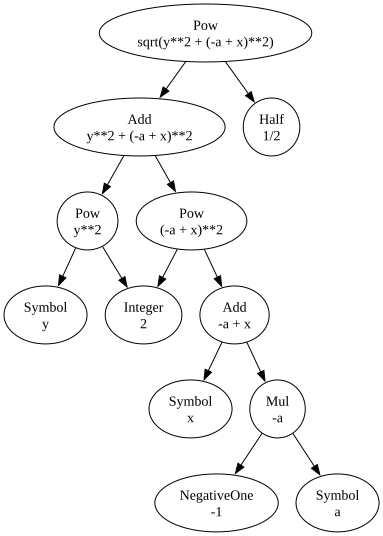

In [18]:
display(B)

In [19]:
sqrt_expr_1 = sqrt(x**2 - 2*a*x + a**2 + y**2)

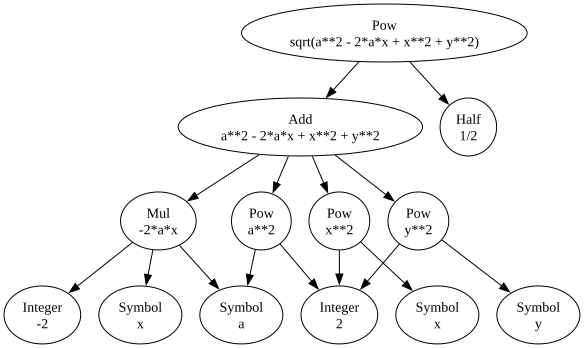

In [20]:
display(sympy_expr_to_graph(sqrt_expr_1))

In [22]:
sym.factor(sqrt_expr_1)

sqrt(a**2 - 2*a*x + x**2 + y**2)

In [23]:
poly = sqrt_expr_1.args[0]
display(poly)

a**2 - 2*a*x + x**2 + y**2

In [24]:
sym.factor(poly,deep=True)

a**2 - 2*a*x + x**2 + y**2

In [28]:
poly_x = poly - y**2

In [29]:
sym.factor(poly_x)

(-a + x)**2

In [30]:
poly_new = sym.factor(poly - y**2) + y**2
display(poly_new)

y**2 + (-a + x)**2

In [37]:
radicand = sqrt_expr_1.args[0]

ax_part = sum(
    term for term in radicand.as_ordered_terms()
    if term.has(a, x) and not term.has(y)
)

rest = radicand - ax_part

sqrt_expr_2 = sqrt(sym.factor(ax_part) + rest)
display(sqrt_expr_2)

sqrt(y**2 + (-a + x)**2)